# Interfacial Tension (IFT) Prediction — XGBoost Pipeline

Rebuilt end-to-end pipeline for predicting **Interfacial Tension (mN/m)** in
nanoparticle-assisted chemical EOR, following the methodology of the companion
manuscript:

> Kandiel, Y.E., Mahmoud, O., Ibrahim, A.F. *Machine Learning-Based
> Interfacial Tension Prediction for Nanoparticles-Assisted Enhanced Oil
> Recovery.*

Only **XGBoost** is used (no model comparison), per project scope, and the
project structure/coding style mirrors `CA/CA_Pipeline.ipynb` exactly
(shared `utils/` modules — no duplicated logic).

### Variable naming convention (identical encoding scheme to the CA paper)
| Category | Codes |
|---|---|
| NPs | 0=None, 1=SiO2, 2=Al2O3, 3=TiO2, 4=Fe3O4, 5=NiO, 6=ZrO2, 7=CuO, 8=CN, 9=MgO, 10=ZnO |
| Chemical Additive | 0=None, 1=Anionic Surf., 2=Cationic Surf., 3=Nonionic Surf., 4=Biosurfactant, 5=Alcohols/Solvents, 6=Anionic Polymer, 7=Nonionic Polymer |

Note: unlike the CA dataset, the IFT dataset has **no rock-type / porosity /
permeability columns** — IFT is a bulk fluid-fluid property, not rock-mediated,
consistent with the source manuscript's feature set.


## 0. Setup

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(".."))
from utils.preprocessing import TabularPreprocessor, PreprocessConfig, NP_TYPE_MAP, CHEM_ADDITIVE_MAP
from utils import model_utils as mu
from utils.optimization import FormulationOptimizer, VariableSpec, MultiObjectiveFormulationOptimizer

from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH   = "../data/IFT_raw_data.xlsx"
FIG_DIR     = "figures"
MODEL_DIR   = "models"
PREFIX      = "ift"
TARGET_COL  = "IFT (mN/m)"
RANDOM_STATE = 42

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


## 1. Data Loading

In [2]:
raw = pd.read_excel(DATA_PATH, sheet_name="rawdata1")
raw.columns = [str(c).strip() for c in raw.columns]
if "iindex" in raw.columns:
    raw = raw.drop(columns=["iindex"])

print("Raw shape:", raw.shape)
raw.head()


Raw shape: (474, 12)


,Salinity (ppm),NPs,NPs Size (nm),NPs Conc. (wt%),Chemical Additive,Additive Conc. (wt%),Viscosity (cP),Oil Viscosity (cP),Oil SG,API,Temp.C,IFT (mN/m)
0,0,0,0,0.00,3,1.0,0.999,64.0,0.940,19.1,15,31.4
1,0,2,35,0.01,3,1.0,0.999,64.0,0.940,19.1,15,31.4
2,30000,0,0,0.00,0,0.0,1.000,5.1,0.826,32.5,15,19.2
3,30000,1,7,0.01,0,0.0,1.010,5.1,0.826,32.5,15,10.9
4,30000,1,7,0.05,0,0.0,1.010,5.1,0.826,32.5,15,7.9


In [3]:
expected_cols = [
    "Salinity (ppm)", "NPs", "NPs Size (nm)", "NPs Conc. (wt%)", "Chemical Additive",
    "Additive Conc. (wt%)", "Viscosity (cP)", "Oil Viscosity (cP)", "Oil SG", "API",
    "Temp.C", TARGET_COL,
]
missing_cols = [c for c in expected_cols if c not in raw.columns]
assert not missing_cols, f"Missing expected columns: {missing_cols}"

print("Missing values per column:")
print(raw.isna().sum())
print("\nDuplicate rows:", raw.duplicated().sum())

# NPs / Chemical Additive are stored as integer codes in this dataset (0-10, 0-7)
raw["NPs"] = raw["NPs"].astype(int).apply(lambda i: f"NP{i}")
raw["Chemical Additive"] = raw["Chemical Additive"].astype(int).apply(lambda i: f"chem{i}")

print("\nCategorical value ranges:")
for c in ["NPs", "Chemical Additive"]:
    print(f"  {c}: {sorted(raw[c].unique(), key=lambda s: int(''.join(filter(str.isdigit, s))))}")

cont_check = ["Salinity (ppm)", "NPs Size (nm)", "NPs Conc. (wt%)", "Additive Conc. (wt%)",
              "Viscosity (cP)", "Oil Viscosity (cP)", "Oil SG", "API", "Temp.C", TARGET_COL]
print("\nContinuous ranges:")
print(raw[cont_check].agg(["min", "max", "mean", "median"]).T.round(3))


Missing values per column:
Salinity (ppm)          0
NPs                     0
NPs Size (nm)           0
NPs Conc. (wt%)         0
Chemical Additive       0
Additive Conc. (wt%)    0
Viscosity (cP)          0
Oil Viscosity (cP)      0
Oil SG                  0
API                     0
Temp.C                  0
IFT (mN/m)              0
dtype: int64

Duplicate rows: 107

Categorical value ranges:
  NPs: ['NP0', 'NP1', 'NP2', 'NP3', 'NP4', 'NP6', 'NP7', 'NP8', 'NP9', 'NP10']
  Chemical Additive: ['chem0', 'chem1', 'chem2', 'chem3', 'chem4', 'chem5', 'chem6', 'chem7']

Continuous ranges:
                         min        max       mean    median
Salinity (ppm)         0.000  150000.00  23120.618  3319.000
NPs Size (nm)          0.000     810.00    110.652    20.000
NPs Conc. (wt%)        0.000       1.00      0.076     0.050
Additive Conc. (wt%)   0.000       9.20      0.345     0.000
Viscosity (cP)         0.353    4919.00     38.626     0.999
Oil Viscosity (cP)     0.900     264.00  

In [4]:
raw["NPs_Label"] = raw["NPs"].map(NP_TYPE_MAP)
raw["Chemical Additive_Label"] = raw["Chemical Additive"].map(CHEM_ADDITIVE_MAP)
raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Salinity (ppm),474.0,NaN,NaN,NaN,23120.618143,38117.891172,0.0,0.0,3319.0,30000.0,150000.0
NPs,474,10,NP1,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NPs Size (nm),474.0,NaN,NaN,NaN,110.651899,240.973412,0.0,8.0,20.0,50.0,810.0
NPs Conc. (wt%),474.0,NaN,NaN,NaN,0.075627,0.109252,0.0,0.0025,0.05,0.1,1.0
Chemical Additive,474,8,chem0,242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Additive Conc. (wt%),474.0,NaN,NaN,NaN,0.344705,1.54497,0.0,0.0,0.0,0.1,9.2
Viscosity (cP),474.0,NaN,NaN,NaN,38.626388,403.097164,0.353,0.999,0.999,1.0315,4919.0
Oil Viscosity (cP),474.0,NaN,NaN,NaN,39.206506,53.231314,0.9,2.02,18.5,98.88,264.0
Oil SG,474.0,NaN,NaN,NaN,0.83815,0.064994,0.73,0.8,0.87,0.88,0.96
API,474.0,NaN,NaN,NaN,38.253333,14.32211,15.5,29.5,32.02,44.4,63.0


## 2. Data Exploration (publication-quality EDA)

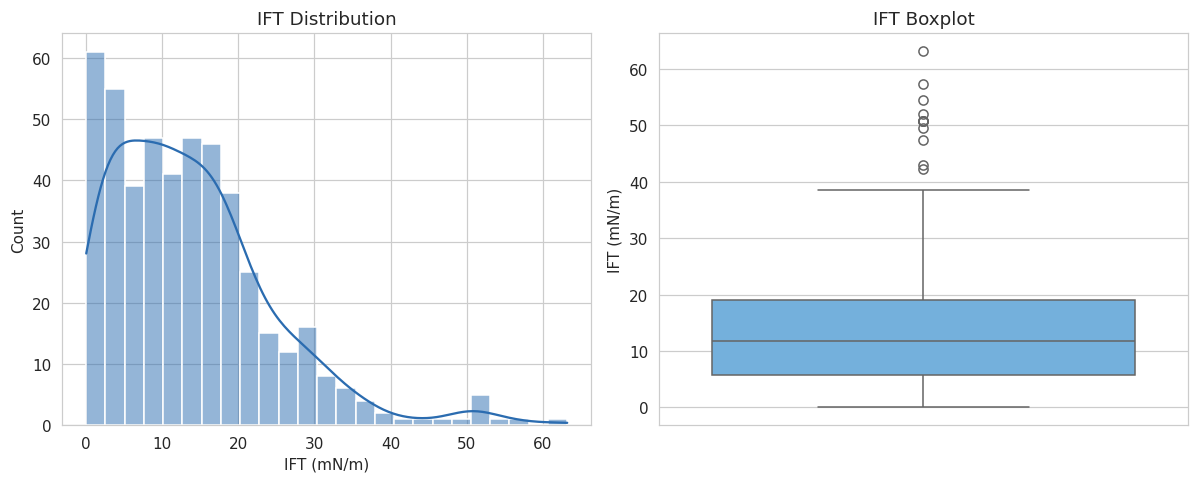

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.histplot(raw[TARGET_COL], bins=25, kde=True, ax=axes[0], color="#2b6cb0")
axes[0].set_title("IFT Distribution")
axes[0].set_xlabel("IFT (mN/m)")

sns.boxplot(y=raw[TARGET_COL], ax=axes[1], color="#63b3ed")
axes[1].set_title("IFT Boxplot")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_target_distribution.png", dpi=200)
plt.show()


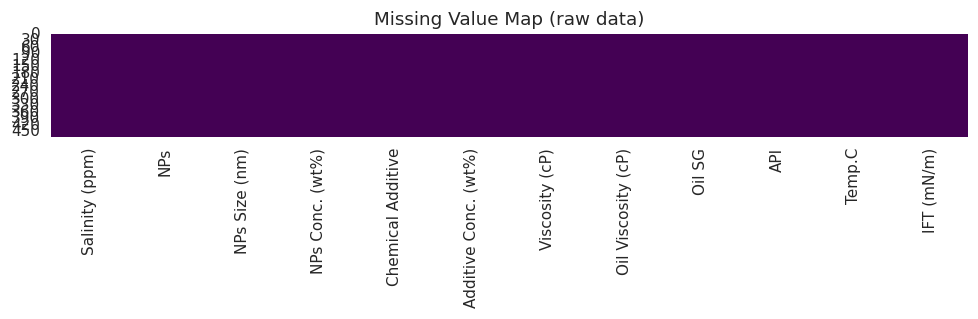

In [6]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(raw[expected_cols].isna(), cbar=False, ax=ax, cmap="viridis")
ax.set_title("Missing Value Map (raw data)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_missing_values.png", dpi=200)
plt.show()


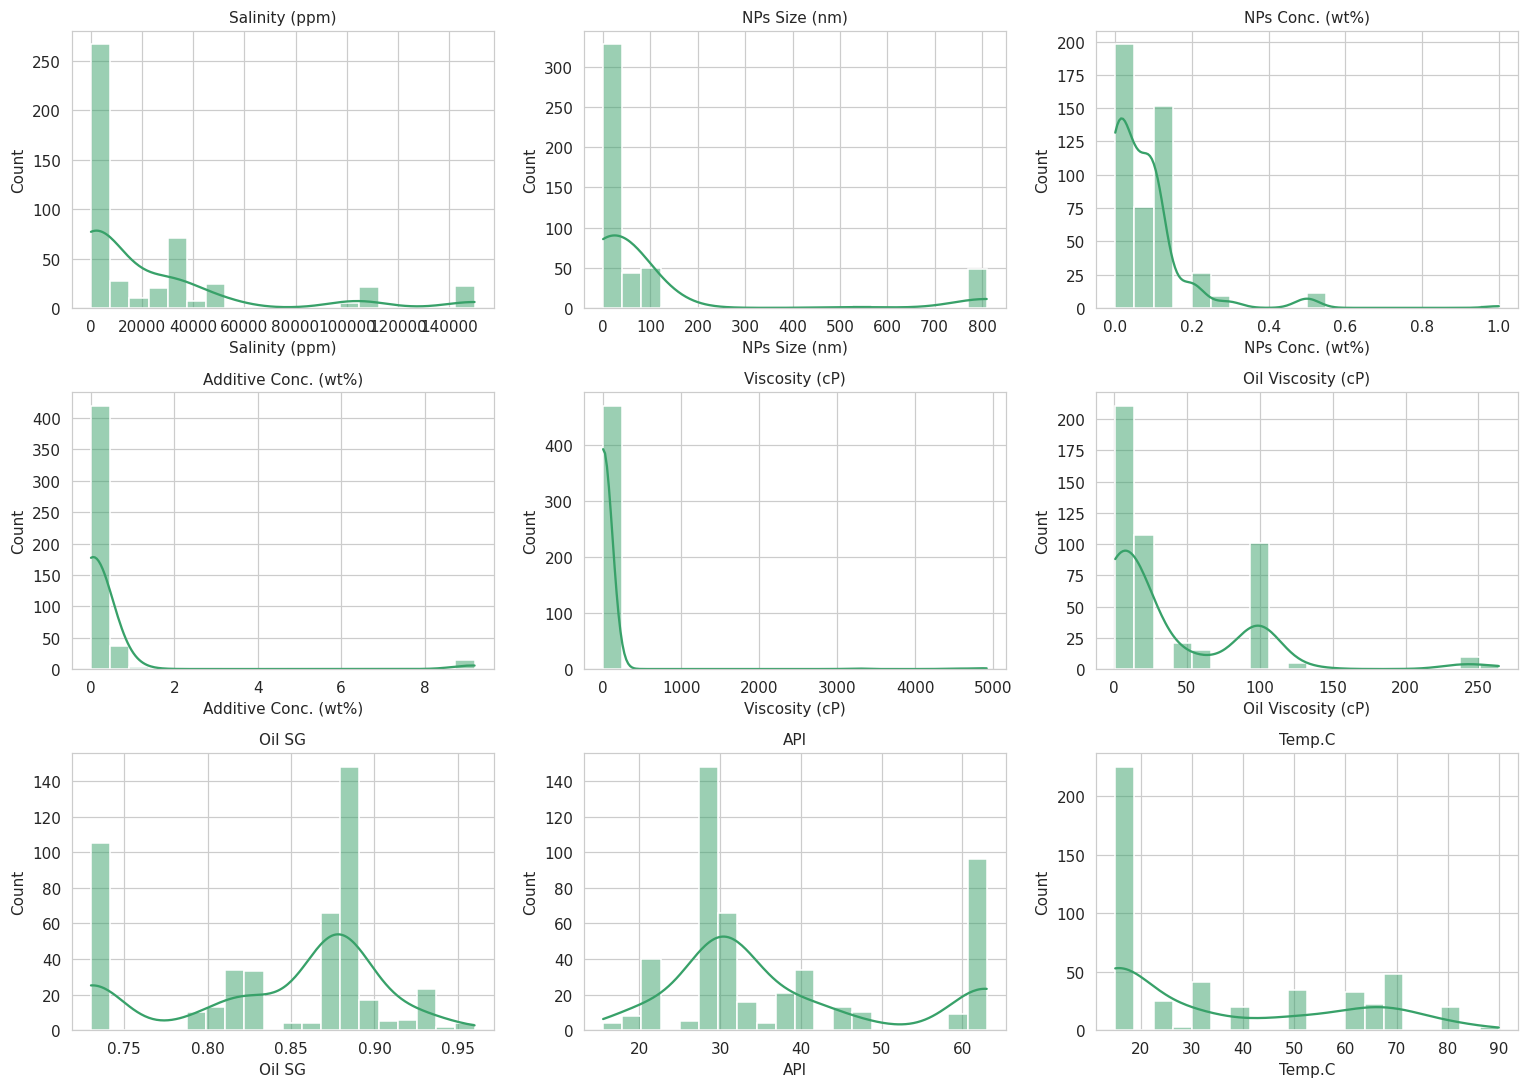

In [7]:
cont_features = ["Salinity (ppm)", "NPs Size (nm)", "NPs Conc. (wt%)", "Additive Conc. (wt%)",
                  "Viscosity (cP)", "Oil Viscosity (cP)", "Oil SG", "API", "Temp.C"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), cont_features):
    sns.histplot(raw[col], bins=20, kde=True, ax=ax, color="#38a169")
    ax.set_title(col, fontsize=10)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_feature_histograms.png", dpi=200)
plt.show()


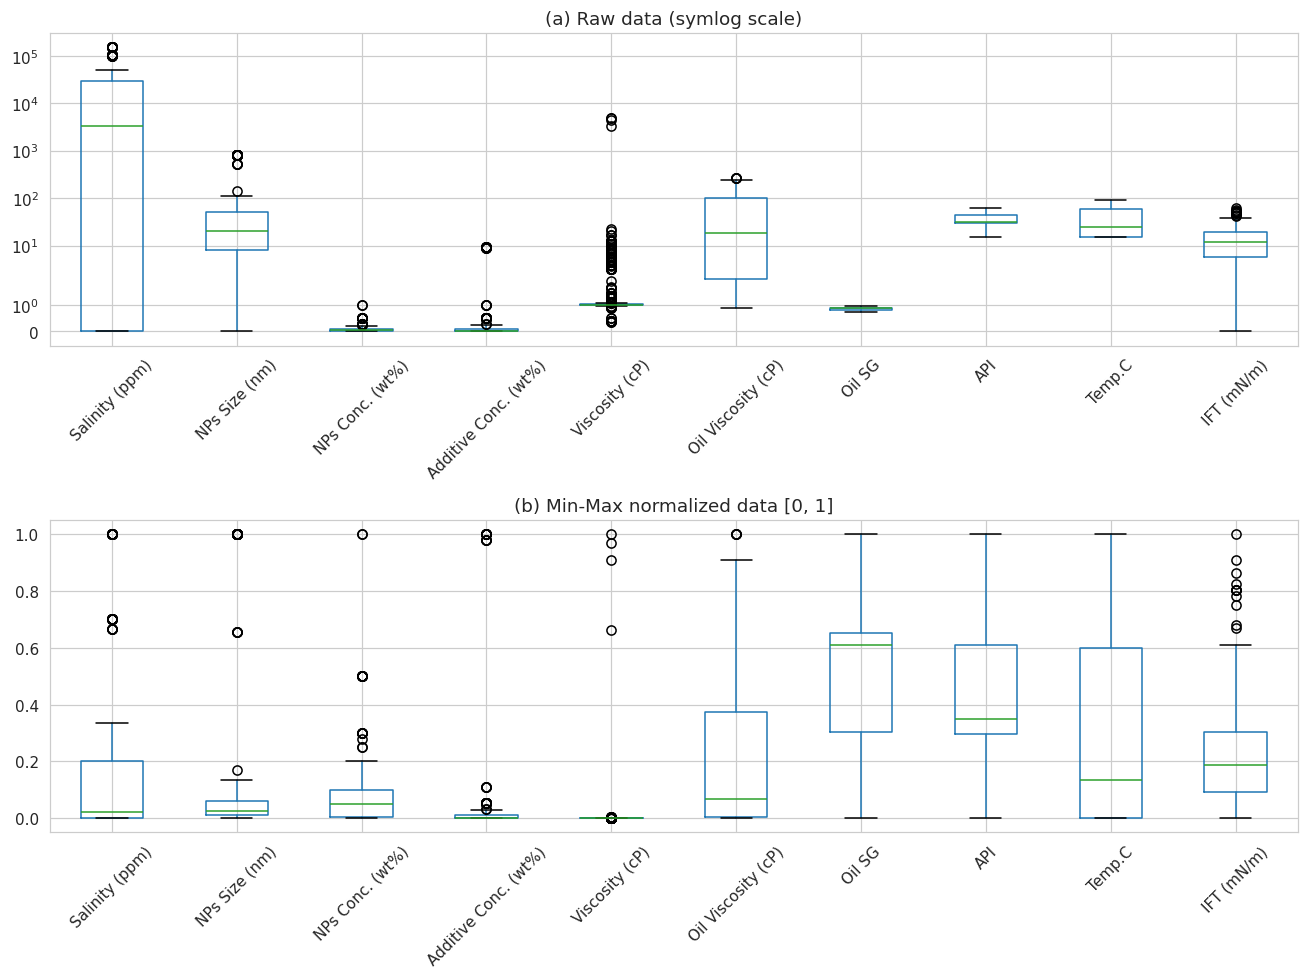

In [8]:
from sklearn.preprocessing import MinMaxScaler
norm_preview = pd.DataFrame(
    MinMaxScaler().fit_transform(raw[cont_features + [TARGET_COL]]),
    columns=cont_features + [TARGET_COL],
)
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
raw[cont_features + [TARGET_COL]].boxplot(ax=axes[0], rot=45)
axes[0].set_yscale("symlog")
axes[0].set_title("(a) Raw data (symlog scale)")
norm_preview.boxplot(ax=axes[1], rot=45)
axes[1].set_title("(b) Min-Max normalized data [0, 1]")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_boxplots_raw_vs_normalized.png", dpi=200)
plt.show()


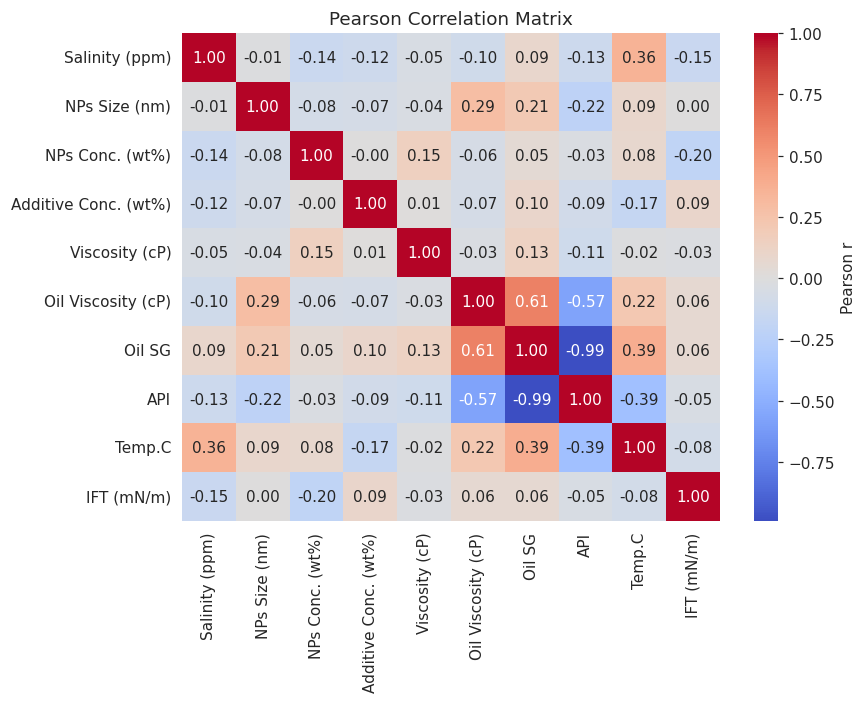

In [9]:
corr = raw[cont_features + [TARGET_COL]].corr(method="pearson")
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Pearson Correlation Matrix")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_correlation_matrix.png", dpi=200)
plt.show()


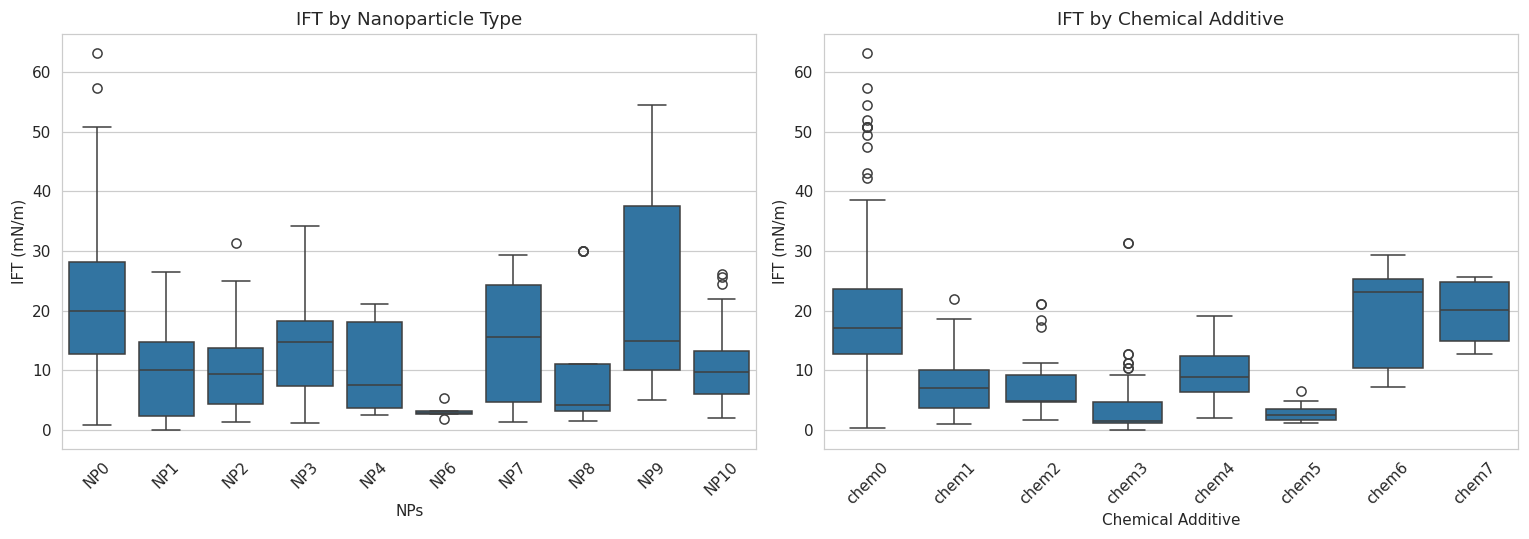

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=raw, x="NPs", y=TARGET_COL, ax=axes[0],
            order=sorted(raw["NPs"].unique(), key=lambda s: int(s[2:])))
axes[0].set_title("IFT by Nanoparticle Type"); axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=raw, x="Chemical Additive", y=TARGET_COL, ax=axes[1],
            order=sorted(raw["Chemical Additive"].unique(), key=lambda s: int(s[4:])))
axes[1].set_title("IFT by Chemical Additive"); axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_ift_by_categorical.png", dpi=200)
plt.show()


## 3. Data Preprocessing

Same methodology and shared code as the CA notebook:

* Outlier trimming (1st/99th percentile on IFT)
* Median imputation
* `ln(1+x)` transform of the skewed features (NP conc., additive conc.,
  salinity, viscosities — all reported as heavily right-skewed in the paper)
* Min-Max scaling of continuous features **and** the target (IFT can be 0,
  and spans 0-63 mN/m, so scaling keeps it on equal footing with other
  bounded features during training)
* One-hot encoding of NPs / Chemical Additive


In [11]:
CONTINUOUS_FEATURES = ["Salinity (ppm)", "NPs Size (nm)", "NPs Conc. (wt%)",
                        "Additive Conc. (wt%)", "Viscosity (cP)", "Oil Viscosity (cP)",
                        "Oil SG", "API", "Temp.C"]
CATEGORICAL_FEATURES = ["NPs", "Chemical Additive"]
LOG_FEATURES = ["Salinity (ppm)", "NPs Conc. (wt%)", "Additive Conc. (wt%)",
                 "Viscosity (cP)", "Oil Viscosity (cP)"]

config = PreprocessConfig(
    target_col=TARGET_COL,
    log_features=LOG_FEATURES,
    continuous_features=CONTINUOUS_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    scale_target=True,
    outlier_trim=True,
    outlier_low_pct=1.0,
    outlier_high_pct=99.0,
)

preprocessor = TabularPreprocessor(config)
X, y, extra = preprocessor.fit_transform(raw[expected_cols])
print("Post-preprocessing shape:", X.shape, "| target:", y.shape)
print(preprocessor.feature_names_out_)


Post-preprocessing shape: (359, 27) | target: (359,)
['Salinity (ppm)', 'NPs Size (nm)', 'NPs Conc. (wt%)', 'Additive Conc. (wt%)', 'Viscosity (cP)', 'Oil Viscosity (cP)', 'Oil SG', 'API', 'Temp.C', 'NPs_NP0', 'NPs_NP1', 'NPs_NP10', 'NPs_NP2', 'NPs_NP3', 'NPs_NP4', 'NPs_NP6', 'NPs_NP7', 'NPs_NP8', 'NPs_NP9', 'Chemical Additive_chem0', 'Chemical Additive_chem1', 'Chemical Additive_chem2', 'Chemical Additive_chem3', 'Chemical Additive_chem4', 'Chemical Additive_chem5', 'Chemical Additive_chem6', 'Chemical Additive_chem7']


In [12]:
# Train (70%) / Validation (15%) / Test (15%), matching the IFT manuscript's split ratio
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")


Train: 251  |  Val: 54  |  Test: 54


## 4. Model Training — XGBoost

In [13]:
tuned_model_untrained = mu.tune_xgboost(
    X_train, y_train, groups=None, n_iter=60, n_splits=10, random_state=RANDOM_STATE,
)
best_params = tuned_model_untrained.get_params()
for k in ["n_jobs", "random_state", "objective", "tree_method"]:
    best_params.pop(k, None)
best_params


Fitting 10 folds for each of 60 candidates, totalling 600 fits


Best CV MSE: 0.007087536066174932
Best params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.001, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.6}


{'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.6,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': True,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.15,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': 1,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 400,
 'num_parallel_tree': None,
 'reg_alpha': 0.001,
 'reg_lambda': 0.5,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 1.0,
 'validate_parameters': None,
 'verbosity': None}

In [14]:
model = mu.train_final_xgboost(X_train, y_train, X_val, y_val, best_params, random_state=RANDOM_STATE)
print("Best iteration:", model.best_iteration)


Best iteration: 146


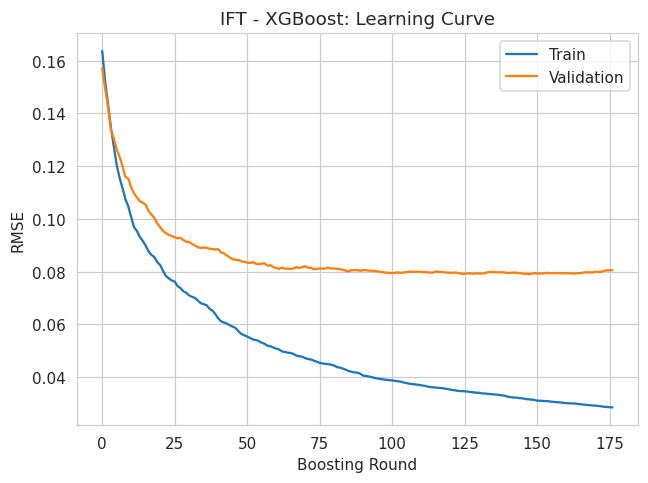

In [15]:
mu.plot_learning_curve(model, title="IFT - XGBoost", save_path=f"{FIG_DIR}/07_learning_curve.png")


## 5. Evaluation

In [16]:
splits = {"Training": (X_train, y_train), "Testing": (X_test, y_test), "Validation": (X_val, y_val)}
metrics = {}
preds_val = {}
for name, (Xs, ys) in splits.items():
    pred_scaled = model.predict(Xs)
    pred = preprocessor.inverse_transform_target(pred_scaled)
    true = preprocessor.inverse_transform_target(ys.values)
    preds_val[name] = (true, pred)
    metrics[name] = mu.regression_metrics(true, pred)
metrics_df = mu.print_metrics_table(metrics, title="IFT - XGBoost Performance (mN/m)")



=== IFT - XGBoost Performance (mN/m) ===
              RMSE     MAE     MAPE      R2  Residual_Std  Residual_Mean
Training    1.6043  1.1782  15.2994  0.9682        1.6043         0.0002
Testing     6.3232  3.6319  67.5644  0.6926        6.2208         1.1333
Validation  4.0095  2.7620  56.4826  0.7817        4.0079        -0.1128


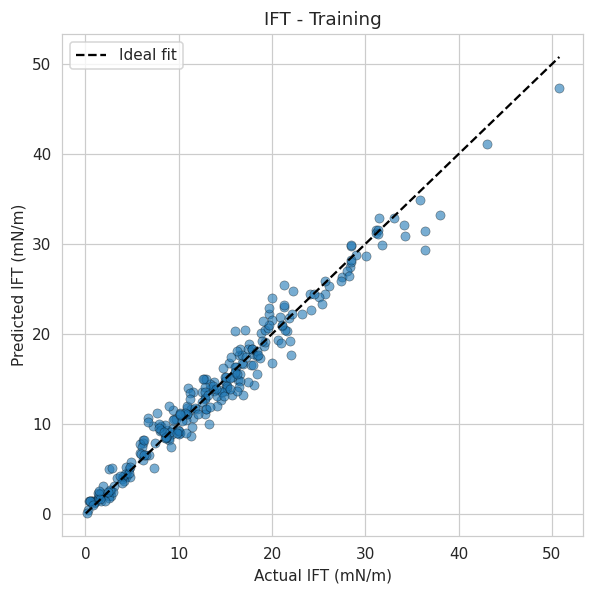

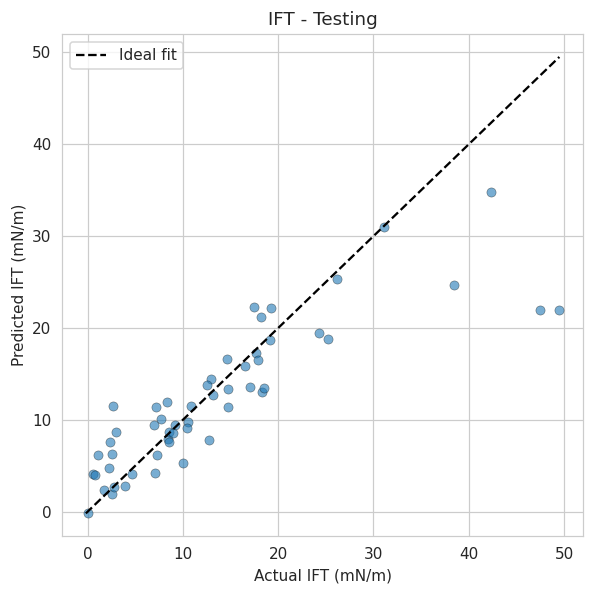

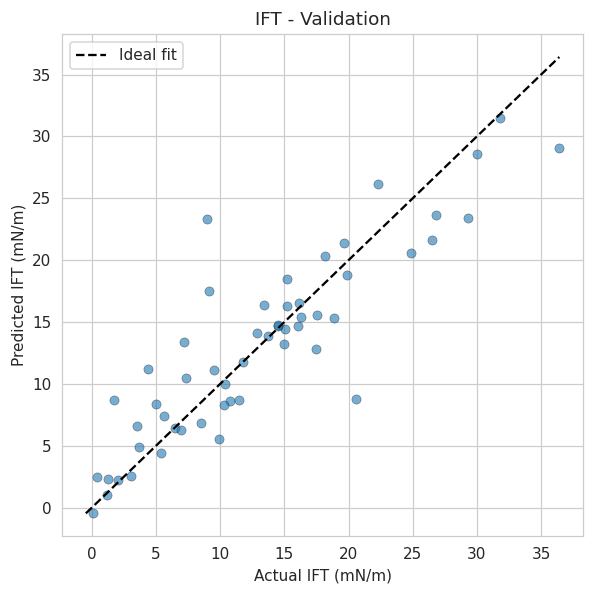

In [17]:
for name, (true, pred) in preds_val.items():
    mu.plot_actual_vs_predicted(true, pred, title=f"IFT - {name}",
                                 save_path=f"{FIG_DIR}/08_actual_vs_pred_{name.lower()}.png",
                                 unit="IFT (mN/m)")


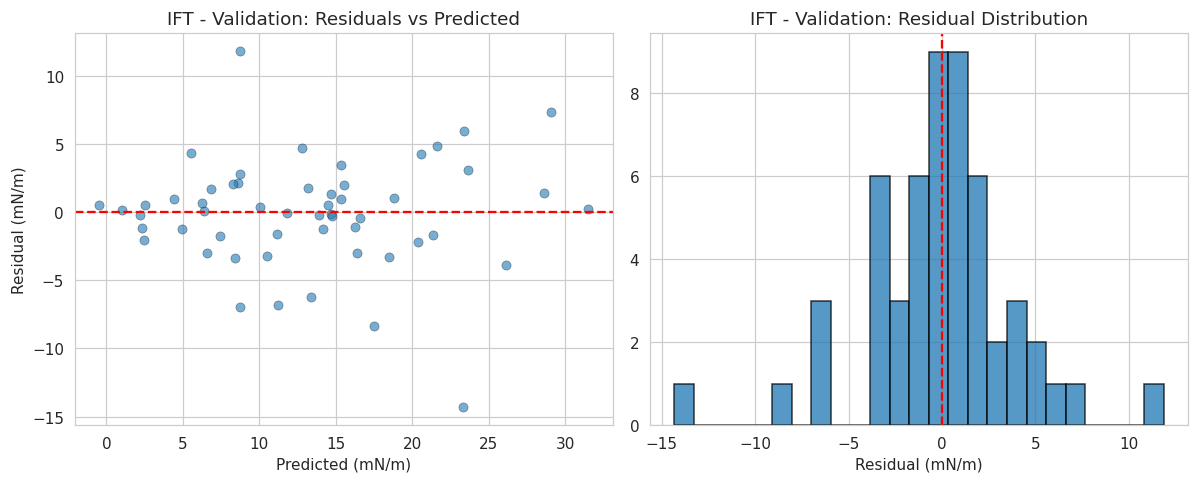

In [18]:
true_val, pred_val = preds_val["Validation"]
mu.plot_residuals(true_val, pred_val, title="IFT - Validation",
                   save_path=f"{FIG_DIR}/09_residuals_validation.png", unit="(mN/m)")


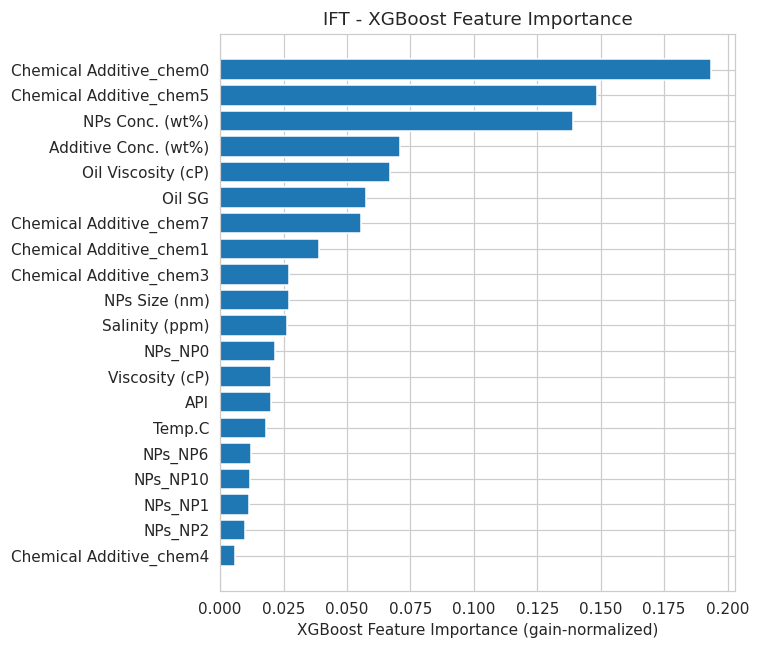

In [19]:
mu.plot_feature_importance(model, preprocessor.feature_names_out_,
                            title="IFT - XGBoost Feature Importance",
                            save_path=f"{FIG_DIR}/10_feature_importance.png")


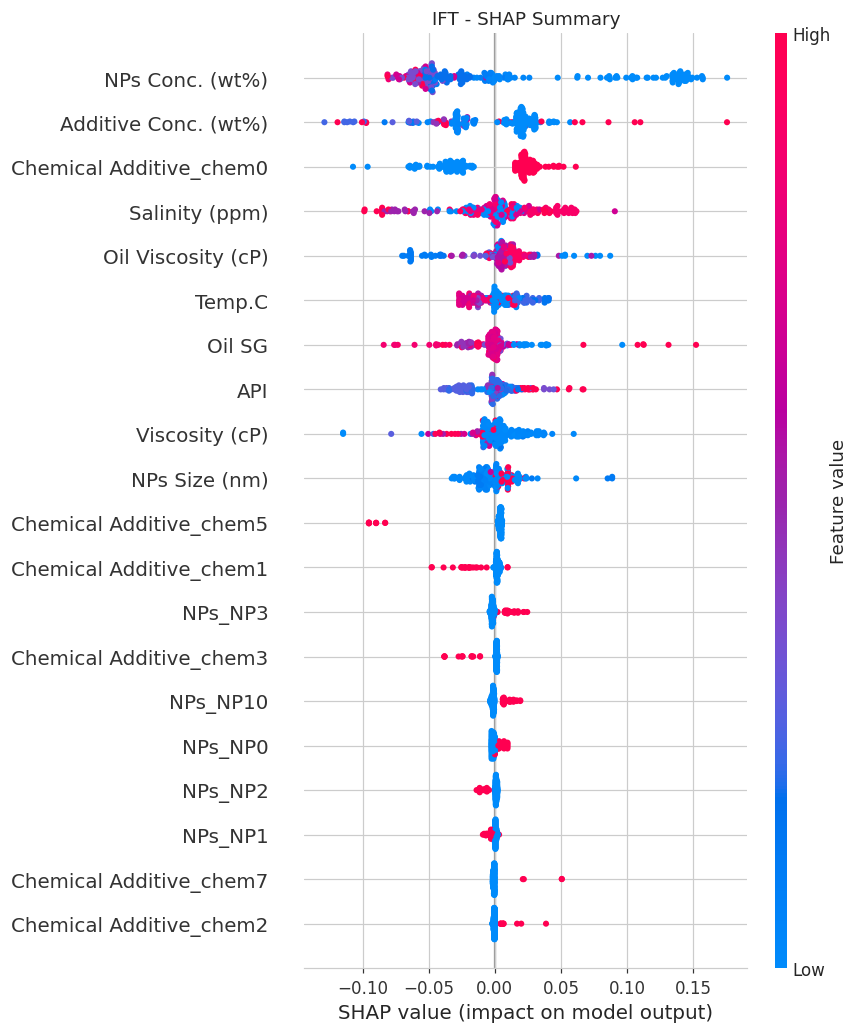

In [20]:
shap_values = mu.plot_shap_summary(model, X_train, title="IFT - SHAP Summary",
                                    save_path=f"{FIG_DIR}/11_shap_summary.png")


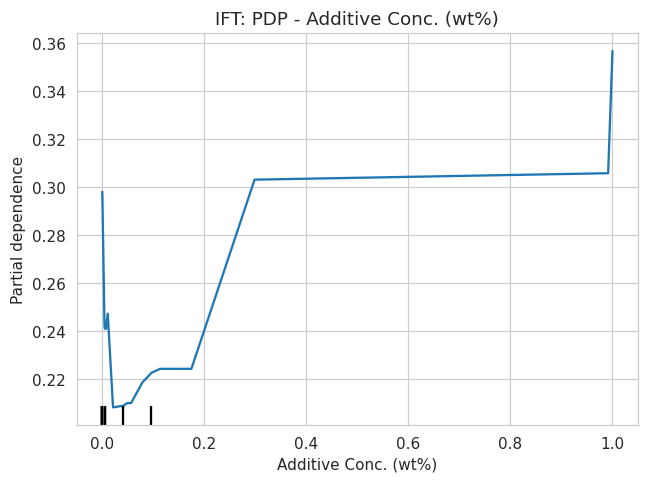

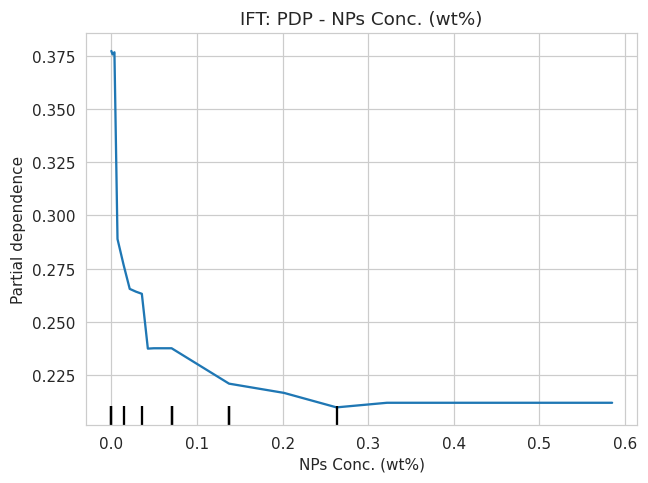

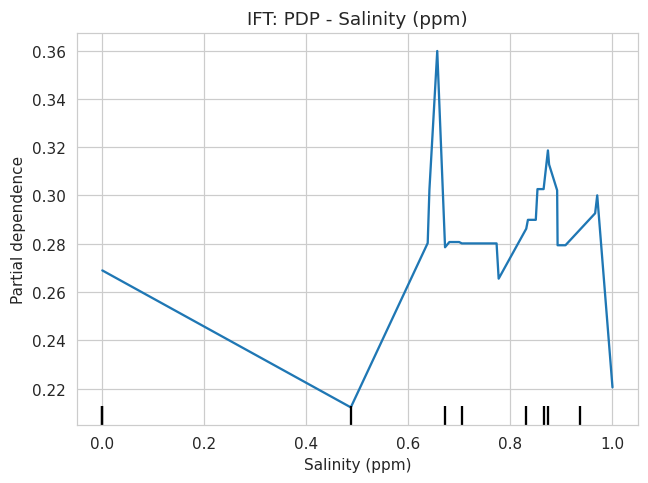

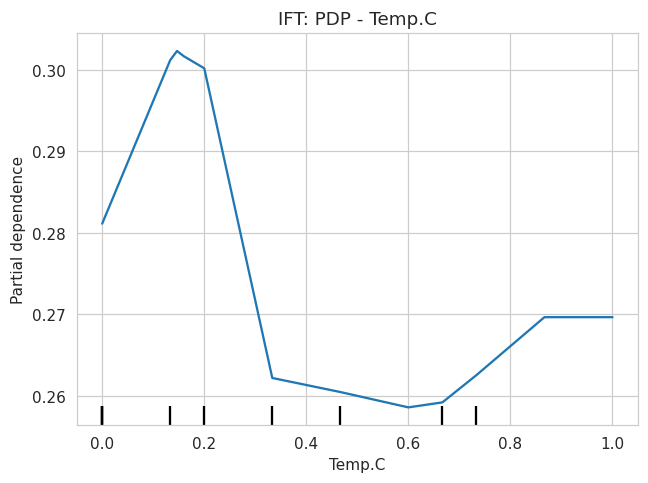

In [21]:
for feat in ["Additive Conc. (wt%)", "NPs Conc. (wt%)", "Salinity (ppm)", "Temp.C"]:
    mu.plot_pdp_1d(model, X_train, feat, title="IFT", unit="(mN/m)",
                    save_path=f"{FIG_DIR}/12_pdp_{feat.split(' ')[0]}.png")


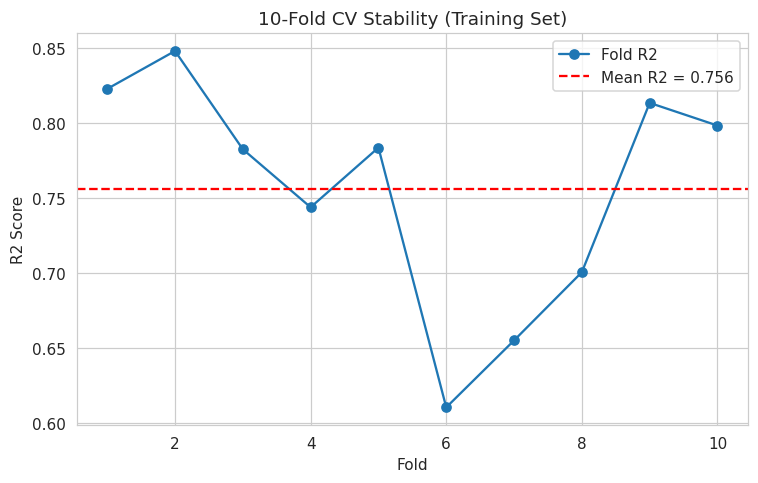

CV R2: 0.756 +/- 0.074


In [22]:
from sklearn.model_selection import KFold
import xgboost as xgb

cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
fold_r2 = []
for fold_i, (tr_idx, te_idx) in enumerate(cv.split(X_train)):
    m = xgb.XGBRegressor(**best_params, objective="reg:squarederror",
                          random_state=RANDOM_STATE, tree_method="hist")
    m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    p = m.predict(X_train.iloc[te_idx])
    fold_r2.append(mu.regression_metrics(y_train.iloc[te_idx], p)["R2"])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, 11), fold_r2, marker="o", label="Fold R2")
ax.axhline(np.mean(fold_r2), color="red", ls="--", label=f"Mean R2 = {np.mean(fold_r2):.3f}")
ax.set_xlabel("Fold"); ax.set_ylabel("R2 Score"); ax.set_title("10-Fold CV Stability (Training Set)")
ax.legend(); fig.tight_layout()
fig.savefig(f"{FIG_DIR}/13_cv_stability.png", dpi=200)
plt.show()
print(f"CV R2: {np.mean(fold_r2):.3f} +/- {np.std(fold_r2):.3f}")


## 6. Save Everything

In [23]:
training_config = {
    "model_type": "XGBRegressor",
    "best_params": best_params,
    "best_iteration": int(model.best_iteration) if model.best_iteration is not None else None,
    "continuous_features": CONTINUOUS_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "log_features": LOG_FEATURES,
    "target_col": TARGET_COL,
    "target_unit": "mN/m",
    "train_size": int(X_train.shape[0]),
    "val_size": int(X_val.shape[0]),
    "test_size": int(X_test.shape[0]),
    "random_state": RANDOM_STATE,
    "np_type_map": NP_TYPE_MAP,
    "chem_additive_map": CHEM_ADDITIVE_MAP,
}
mu.save_model_bundle(model, preprocessor, MODEL_DIR, PREFIX, training_config, metrics)


Saved model bundle to: models
  - ift_feature_list.json
  - ift_feature_metadata.json
  - ift_metrics.json
  - ift_preprocessor.pkl
  - ift_training_configuration.json
  - xgb_ift.pkl


## 7. Prediction Function

In [24]:
from utils.predict import ModelBundle

def predict_ift(input_dictionary: dict) -> dict:
    """
    Example
    -------
    predict_ift({
        "Salinity (ppm)": 30000, "NPs": "NP9", "NPs Size (nm)": 20,
        "NPs Conc. (wt%)": 0.3, "Chemical Additive": "chem1",
        "Additive Conc. (wt%)": 0.1, "Viscosity (cP)": 1.0,
        "Oil Viscosity (cP)": 20, "Oil SG": 0.86, "API": 33, "Temp.C": 25,
    })
    """
    bundle = ModelBundle(MODEL_DIR, PREFIX)
    return bundle.predict(input_dictionary)

predict_ift({
    "Salinity (ppm)": 30000, "NPs": "NP9", "NPs Size (nm)": 20,
    "NPs Conc. (wt%)": 0.3, "Chemical Additive": "chem1",
    "Additive Conc. (wt%)": 0.1, "Viscosity (cP)": 1.0,
    "Oil Viscosity (cP)": 20, "Oil SG": 0.86, "API": 33, "Temp.C": 25,
})


{'prediction': 9.265206336975098,
 'ci_95_lower': 1.4065857006435794,
 'ci_95_upper': 17.123826973306617,
 'validation_rmse': 4.009500324658938}

## 8. Optimization Module — Maximize IFT Reduction

"Maximizing IFT reduction" = **minimizing predicted IFT**. Example 2 from the
project brief.


In [25]:
opt = FormulationOptimizer(model=model, preprocessor=preprocessor,
                            continuous_features=CONTINUOUS_FEATURES,
                            categorical_features=CATEGORICAL_FEATURES)

ALL_NPS = [f"NP{i}" for i in range(11)]
ALL_CHEMS = [f"chem{i}" for i in range(8)]

variables_ift = [
    VariableSpec("Oil Viscosity (cP)", "fixed", value=20),
    VariableSpec("Oil SG", "fixed", value=0.86),
    VariableSpec("API", "fixed", value=33),
    VariableSpec("Viscosity (cP)", "fixed", value=1.0),
    VariableSpec("Temp.C", "bounded", low=15, high=90),
    VariableSpec("Salinity (ppm)", "bounded", low=0, high=150000),
    VariableSpec("NPs", "categorical", choices=ALL_NPS),
    VariableSpec("NPs Size (nm)", "bounded", low=0, high=100),
    VariableSpec("NPs Conc. (wt%)", "bounded", low=0, high=1.0),
    VariableSpec("Chemical Additive", "categorical", choices=ALL_CHEMS),
    VariableSpec("Additive Conc. (wt%)", "bounded", low=0, high=1.0),
]

result_ift = opt.minimize(variables_ift, n_trials=250)   # minimize IFT = maximize IFT reduction
print("Minimum predicted IFT:", round(result_ift["best_value"], 3), "mN/m")
print("Best formulation:")
for k, v in result_ift["best_formulation"].items():
    print(f"  {k}: {v}")


Minimum predicted IFT: -0.182 mN/m
Best formulation:
  Temp.C: 67.51666936443384
  Salinity (ppm): 727.1249642501207
  NPs: NP9
  NPs Size (nm): 85.22433584662603
  NPs Conc. (wt%): 0.7856915827184547
  Chemical Additive: chem5
  Additive Conc. (wt%): 0.7457405505535291


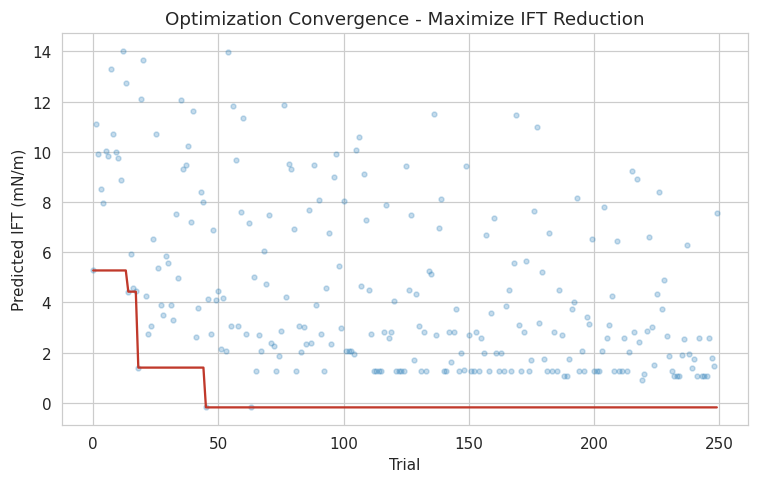

In [26]:
history_df = pd.DataFrame(result_ift["history"])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history_df["trial"], history_df["value"].cummin(), color="#c0392b")
ax.scatter(history_df["trial"], history_df["value"], alpha=0.25, s=10)
ax.set_xlabel("Trial"); ax.set_ylabel("Predicted IFT (mN/m)")
ax.set_title("Optimization Convergence - Maximize IFT Reduction")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/14_optimization_convergence.png", dpi=200)
plt.show()


## 9. Multi-Objective Optimization — Simultaneously Minimize CA **and** IFT

Example 3 from the project brief: fix Temperature and Salinity, and only
optimize NP type, NP concentration, and chemical additive — jointly
minimizing both Contact Angle (from the CA model) and IFT (from this model).

This cell requires that `CA/CA_Pipeline.ipynb` has already been run so that
`CA/models/xgb_ca.pkl` + `CA/models/ca_preprocessor.pkl` exist.


In [27]:
from utils.predict import ModelBundle as _MB

CA_MODEL_DIR = "../CA/models"
ca_bundle_path = os.path.join(CA_MODEL_DIR, "xgb_ca.pkl")

if not os.path.exists(ca_bundle_path):
    print("CA model not found yet - run CA/CA_Pipeline.ipynb first, then re-run this cell.")
else:
    ca_bundle = _MB(CA_MODEL_DIR, "ca")

    mo_opt = MultiObjectiveFormulationOptimizer(
        model_a=ca_bundle.model, preproc_a=ca_bundle.preprocessor, direction_a="minimize",
        model_b=model, preproc_b=preprocessor, direction_b="minimize",
    )

    # Shared + model-specific fixed variables. Both models will receive the
    # full row (extra keys are simply ignored by each model's TabularPreprocessor).
    variables_mo = [
        VariableSpec("Rock Type", "fixed", value="R1"),
        VariableSpec("Porosity (%)", "fixed", value=18),
        VariableSpec("Permeability (mD)", "fixed", value=50),
        VariableSpec("Sample State", "fixed", value="S3"),
        VariableSpec("Viscosity (cP)", "fixed", value=1.0),
        VariableSpec("Oil Viscosity (cP)", "fixed", value=20),
        VariableSpec("Oil SG", "fixed", value=0.86),
        VariableSpec("API", "fixed", value=33),
        VariableSpec("Temp.", "fixed", value=50),     # fixed, per Example 3
        VariableSpec("Temp.C", "fixed", value=50),    # same value, IFT model's column name
        VariableSpec("Salinity (ppm)", "fixed", value=30000),  # fixed, per Example 3
        VariableSpec("NPs", "categorical", choices=ALL_NPS),                 # optimize
        VariableSpec("NPs Size (nm)", "bounded", low=5, high=60),
        VariableSpec("NPs Conc. (wt%)", "bounded", low=0.0, high=1.0),       # optimize
        VariableSpec("Chemical Additive", "categorical", choices=ALL_CHEMS), # optimize
        VariableSpec("Additive Conc. (wt%)", "bounded", low=0.0, high=0.5),
    ]

    mo_result = mo_opt.optimize(variables_mo, n_trials=300)
    pareto_df = mo_result["pareto_front"].rename(
        columns={"objective_a": "Predicted_CA_deg", "objective_b": "Predicted_IFT_mNm"}
    )
    display(pareto_df.head(15))


,trial,Predicted_CA_deg,Predicted_IFT_mNm,NPs,NPs Size (nm),NPs Conc. (wt%),Chemical Additive,Additive Conc. (wt%)
0,156,31.422237,8.572564,NP6,16.713029,0.498196,chem3,0.137080
1,247,31.422237,8.572564,NP6,16.713029,0.498196,chem3,0.172834
2,235,33.673965,7.933742,NP9,16.713029,0.549227,chem3,0.133514
3,276,33.673965,7.933742,NP9,16.713029,0.549227,chem3,0.161478
4,245,34.248081,5.427841,NP0,16.713029,0.424131,chem5,0.321283
5,267,35.153378,4.668689,NP0,16.713029,0.424131,chem5,0.100467
6,286,35.628540,3.863673,NP7,16.713029,0.459800,chem5,0.087183


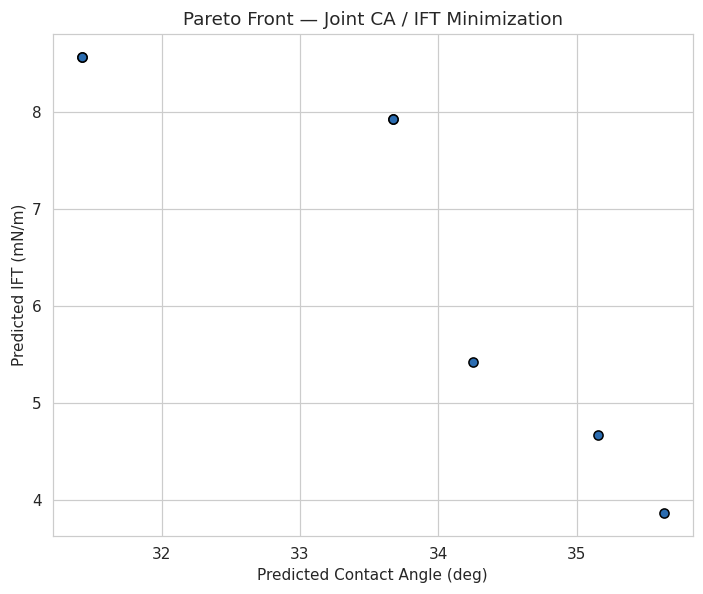

In [28]:
if os.path.exists(ca_bundle_path):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.scatter(pareto_df["Predicted_CA_deg"], pareto_df["Predicted_IFT_mNm"], c="#2b6cb0", edgecolor="k")
    ax.set_xlabel("Predicted Contact Angle (deg)")
    ax.set_ylabel("Predicted IFT (mN/m)")
    ax.set_title("Pareto Front — Joint CA / IFT Minimization")
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/15_pareto_front_ca_ift.png", dpi=200)
    plt.show()


## Summary & Next Steps

All artifacts required for deployment are saved under `IFT/models/`:
`xgb_ift.pkl`, `ift_preprocessor.pkl`, `ift_feature_list.json`,
`ift_feature_metadata.json`, `ift_training_configuration.json`, `ift_metrics.json`.

Together with `CA/models/`, these two self-contained model bundles are
everything the FastAPI/Streamlit calculator (see `deployment/`) needs to serve
both **Prediction Mode** (CA and IFT from user inputs) and **Optimization
Mode** (single- or multi-objective formulation search) without retraining.
